## Name : Ankit Vaghela
## USN no : 1AUA23BCS009
## Batch : B1

# Lab 2 – Warm-Up: Vectors and Dot

## Part A — Implement Perceptron (Step Activation) (Classic ML)

## Steps 
### 1. Setup Python environment (NumPy, Matplotlib) 
### 2. Generate synthetic dataset (linearly separable) 
### 3. Implement: 
###       a. dot product 
###       b. bias addition 
###       c. step activation 
### 4. Train using Perceptron learning rule 
### 5. Plot: 
###       a. dataset points 
###       b. decision boundary

In [42]:
import numpy as np
import matplotlib.pyplot as plt


In [43]:
# Manually given input data (X) and labels (y)

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],
    [-1, -2],
    [-2, -1],
    [-2, -3],
    [-3, -2]
])

y = np.array([1, 1, 1, 1, 0, 0, 0, 0])


In [44]:
X.shape

(8, 2)

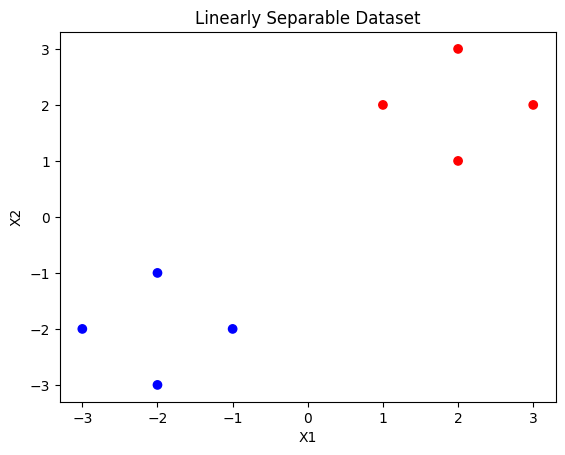

In [45]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title("Linearly Separable Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


In [46]:
def net_input(x, w, b):
    return np.dot(x, w) + b


In [47]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10


In [48]:
def step_function(z):
    return 1 if z >= 0 else 0


In [49]:
for epoch in range(epochs):
    print("\nEpoch:", epoch+1)
    for i in range(len(X)):
        
        z = np.dot(X[i], weights) + bias
        y_pred = step_function(z)
        
        error = y[i] - y_pred
        
        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error
        
        print("Input:", X[i], "Pred:", y_pred, "Actual:", y[i])




Epoch: 1
Input: [1 2] Pred: 1 Actual: 1
Input: [2 1] Pred: 1 Actual: 1
Input: [2 3] Pred: 1 Actual: 1
Input: [3 2] Pred: 1 Actual: 1
Input: [-1 -2] Pred: 1 Actual: 0
Input: [-2 -1] Pred: 0 Actual: 0
Input: [-2 -3] Pred: 0 Actual: 0
Input: [-3 -2] Pred: 0 Actual: 0

Epoch: 2
Input: [1 2] Pred: 1 Actual: 1
Input: [2 1] Pred: 1 Actual: 1
Input: [2 3] Pred: 1 Actual: 1
Input: [3 2] Pred: 1 Actual: 1
Input: [-1 -2] Pred: 0 Actual: 0
Input: [-2 -1] Pred: 0 Actual: 0
Input: [-2 -3] Pred: 0 Actual: 0
Input: [-3 -2] Pred: 0 Actual: 0

Epoch: 3
Input: [1 2] Pred: 1 Actual: 1
Input: [2 1] Pred: 1 Actual: 1
Input: [2 3] Pred: 1 Actual: 1
Input: [3 2] Pred: 1 Actual: 1
Input: [-1 -2] Pred: 0 Actual: 0
Input: [-2 -1] Pred: 0 Actual: 0
Input: [-2 -3] Pred: 0 Actual: 0
Input: [-3 -2] Pred: 0 Actual: 0

Epoch: 4
Input: [1 2] Pred: 1 Actual: 1
Input: [2 1] Pred: 1 Actual: 1
Input: [2 3] Pred: 1 Actual: 1
Input: [3 2] Pred: 1 Actual: 1
Input: [-1 -2] Pred: 0 Actual: 0
Input: [-2 -1] Pred: 0 Actual: 0
In

In [50]:
print("Final Weights:", weights)
print("Final Bias:", bias)



Final Weights: [0.1 0.2]
Final Bias: -0.1


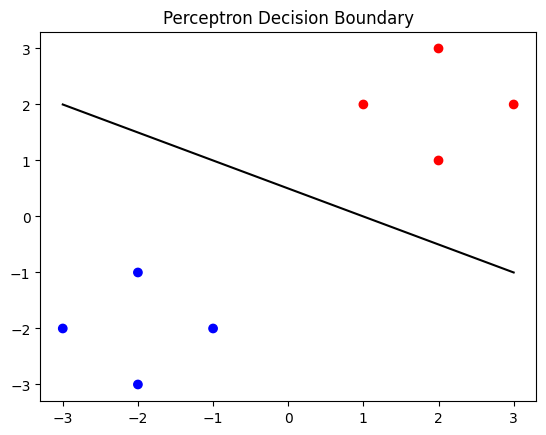

In [51]:
x1 = np.linspace(-3, 3, 100)
x2 = -(weights[0]*x1 + bias) / weights[1]

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.plot(x1, x2, 'k')
plt.title("Perceptron Decision Boundary")
plt.show()


## Part B — Upgrade to “Neuron with Sigmoid” (DL direction, but still 1 neuron) 
## What changes from Part A? 
### • Activation changes: 
###    o Step → Sigmoid 
### • Output becomes probability-like 
### • Training uses gradient descent for a single neuron 
## Steps 
### 6. Replace step activation with: 
###    a. Sigmoid activation 
### 7. Use loss function: 
###    a. Binary cross entropy (or MSE, your choice) 
### 8. Train using gradient descent weight update (single neuron) 
### 9. Plot: 
###    a. loss vs epochs 
###    b. decision boundary

In [52]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [53]:
def mse(y, y_hat):
    return np.mean((y - y_hat)**2)


In [54]:
lr = 0.1
epochs = 100

w = np.zeros(X.shape[1])
b = 0
losses = []

for _ in range(epochs):
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)

    loss = mse(y, y_hat)
    losses.append(loss)

    dw = np.dot(X.T, (y_hat - y)) / len(y)
    db = np.mean(y_hat - y)

    w = w - lr * dw
    b = b - lr * db


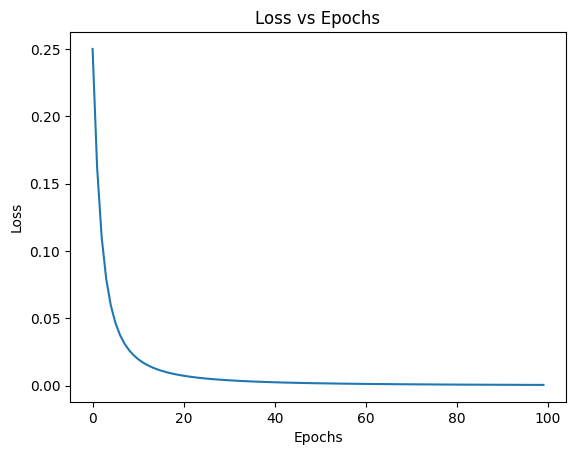

In [55]:
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


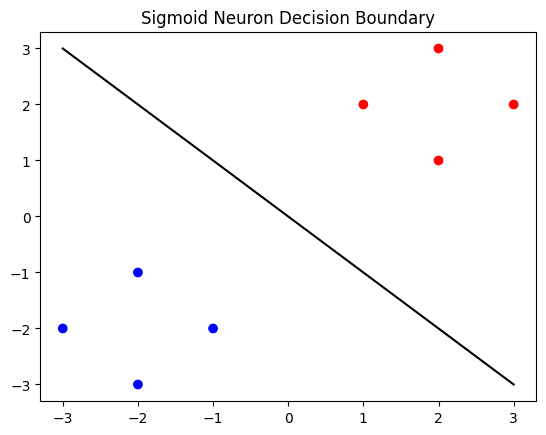

In [56]:
x1 = np.linspace(-3, 3, 100)
x2 = -(w[0]*x1 + b) / w[1]

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.plot(x1, x2, 'k')
plt.title("Sigmoid Neuron Decision Boundary")
plt.show()
